# SOM Sequence
Example training SOM on 7 day sequences during summer.

In [1]:
from pathlib import Path
from datetime import date
import matplotlib.pyplot as plt
import numpy as np

from analysis.som import DataConfig, DataLoader, SOM, GHIPlotter
from analysis.dataloader import AUSTRALIA_EXTENT

1. Getting data from Thredds server

In [ ]:
start = date(2020,12,1)
end = date(2021, 2, 28)
# Load data for 2020-2021 summer. Will load entire data set into RAM
ghi_data = DataLoader.from_thredds(
    start, 
    end, 
    time_res="d",
    extent=AUSTRALIA_EXTENT,
    resolution_km=55 # Default resolution 55 is lower than resolution of data set
    )
# Data is automatically regridded to Albers equal area projection

Batches: 100%|██████████| 3/3 [04:43<00:00, 94.58s/batch]


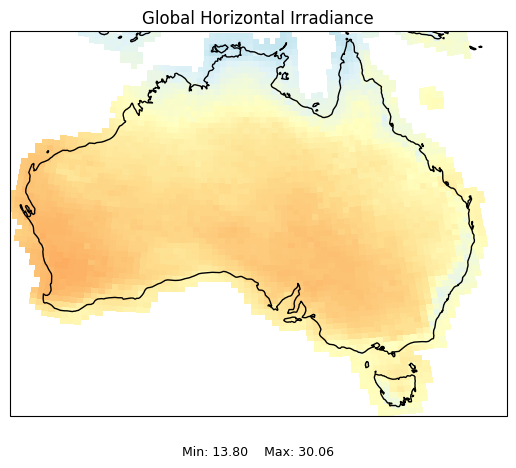

In [3]:
# Plotting mean ghi
GHIPlotter.plot_ghi(ghi_data.data.mean(dim="time"))

2. Configure the data preprocessing.
```overlap_sequences``` determines whether the data is split into disjoint weeks or a 7 day sequence starting on each day is created.


In [4]:
config = DataConfig(
    regrid_equal_area=True,
    season="DJF",
    representation="weekly_sequence",
    overlap_sequences=False, 
    seq_len= 7, # Can be changed for other lengths
)

3. Configure SOM

In [5]:
som_training_args = dict(
        topology="hexagonal",
        epochs=100,
        batch_size=4,
        initialization_mode="random",
        lr_decay_function="lr_linear_decay_to_zero",
        sigma_decay_function="sig_linear_decay_to_one",
        sigma=3
        )
# Will update the default training args in som.py

# Train the SOM
som = SOM(ghi_data, config).fit(
        rows=3,
        cols=3,
        **som_training_args,
    )

train_som: final quantization error 818.560, topographic error 0.00%


4. Plot results

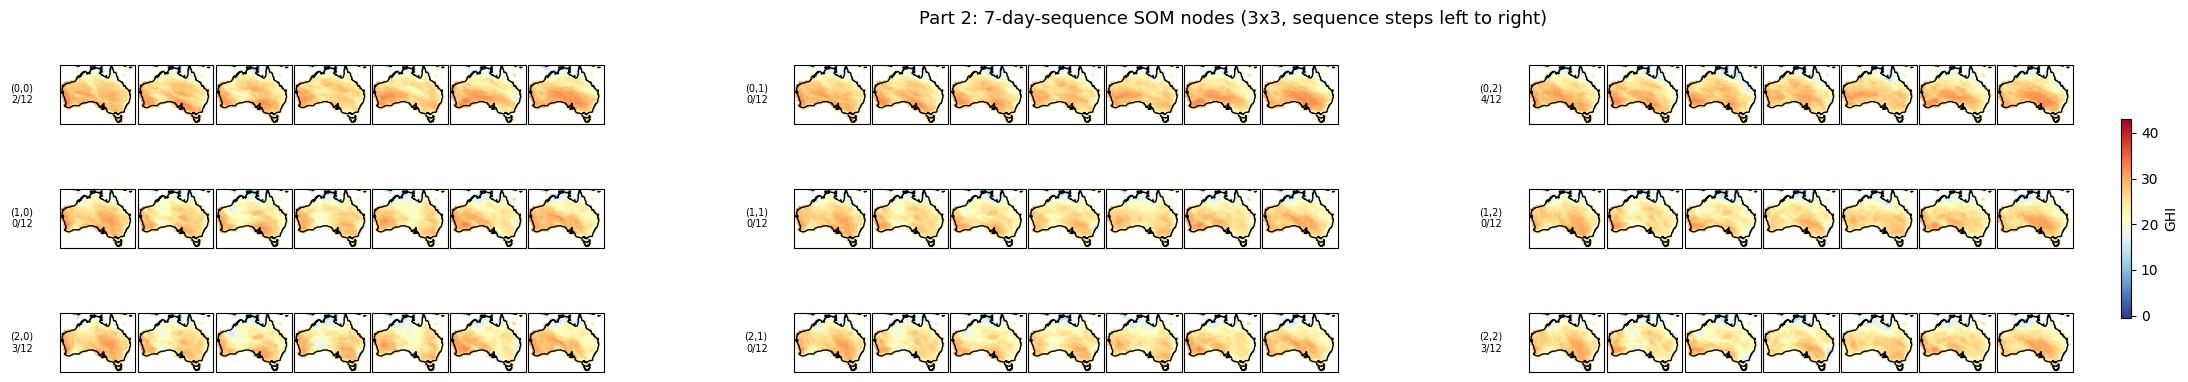

In [11]:
# Weight vector of each node
nodes_figure = som.plot_sequence_nodes(units_label="GHI")

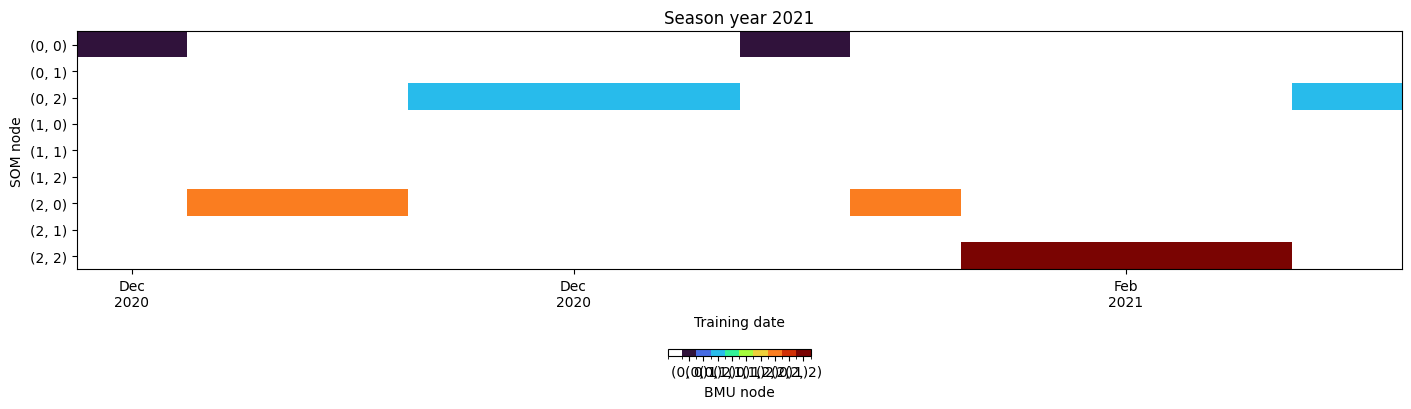

In [12]:
# Timeline showing the BMU each sample is assigned to
timeline_figure, assignments = som.plot_bmu_timeline(year_by_year=True)

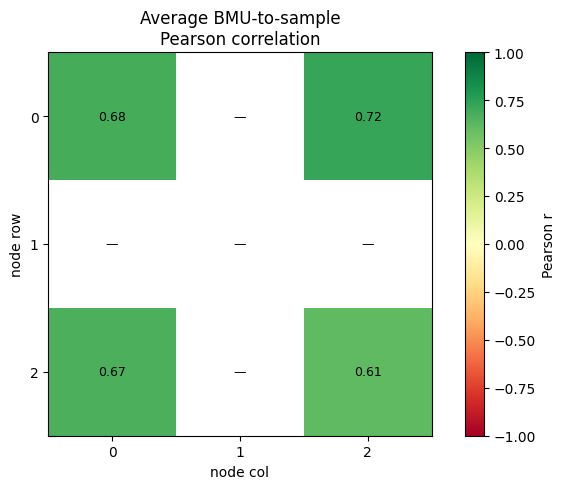

In [13]:
# Plot average correlation between each node and all real samples assigned to it
correlation_figure, correlations = som.plot_bmu_correlations(figsize=(7, 5))